#Notebook 02: Elasticidad de Precio

En Este Notebook , vamos a responder a intentar responder a la elasticidad del producto a la seiguiente pregunta  ¿Cuánto baja el volumen de ventas si subimos el precio
un 10% en cada categoría de producto?
Al Director Comercial le interesa saber en qué categorías puede subir precio sin perder mucho volumen (inelásticas) y en cuáles no debería hacerlo (elásticas).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

Mounted at /content/drive


In [2]:

RUTA_DATOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/dunnhumby/'
RUTA_PROCESADOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/processed/'

trans = pd.read_csv(RUTA_PROCESADOS + 'transactions_clean.csv')
products = pd.read_csv(RUTA_DATOS + 'product.csv')

In [3]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576815 entries, 0 to 2576814
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
 12  tiene_retail_disc  bool   
 13  tiene_coupon_disc  bool   
 14  tiene_match_disc   bool   
 15  PRICE_PAID         float64
 16  PRICE_SHELF        float64
 17  DISCOUNT_PCT       float64
dtypes: bool(3), float64(7), int64(8)
memory usage: 302.3 MB


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int64 
 1   MANUFACTURER          92353 non-null  int64 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.9+ MB


Las transacciones tienen PRODUCT_ID pero no sabemos a qué categoría pertenece cada producto. Esa información está en la tabla 'product.csv', en la columna DEPARTMENT.
Hacemos un merge (JOIN) para añadir DEPARTMENT a cada transacción.

In [5]:
# Nos quedamos solo con las columnas que necesitamos
products_simple = products[['PRODUCT_ID', 'DEPARTMENT']]

In [6]:
# Unir: añadir DEPARTMENT a cada transacción
trans = trans.merge(products_simple, on='PRODUCT_ID', how='left')

In [7]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576815 entries, 0 to 2576814
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
 12  tiene_retail_disc  bool   
 13  tiene_coupon_disc  bool   
 14  tiene_match_disc   bool   
 15  PRICE_PAID         float64
 16  PRICE_SHELF        float64
 17  DISCOUNT_PCT       float64
 18  DEPARTMENT         object 
dtypes: bool(3), float64(7), int64(8), object(1)
memory usage: 321.9+ MB


No podemos usar las transacciones individuales directamente para la regresión. porque cada fila es una compra de un producto. La mayoría tienen QUANTITY = 1. Si hacemos la regresión así, no vemos cómo el precio afecta al VOLUMEN TOTAL de una categoría.
 Lo que necesitamos es: para cada categoría, cada semana y cada tienda, ¿cuál fue el precio medio y cuántas unidades se vendieron en total?



In [8]:
print(trans['QUANTITY'].value_counts().head(10))

QUANTITY
1     2046597
2      372298
3       66957
4       38667
5       10918
6        8981
8        2531
10       2219
7        1379
12        909
Name: count, dtype: int64


# Agregación datos por departamento por semana por tienda
Queremos obtener ⁉
- qty_total:  cantidad total vendida (volumen)
- price_mean: precio medio de estantería

In [9]:
# Agrupar por departamento, semana y tienda
datos_agrupados = trans.groupby(['DEPARTMENT', 'WEEK_NO', 'STORE_ID']).agg(
    qty_total   = ('QUANTITY', 'sum'),
    price_mean  = ('PRICE_SHELF', 'mean'),
).reset_index()

In [10]:
ejemplo = datos_agrupados[datos_agrupados['DEPARTMENT'] == 'GROCERY'].head(5)
print(ejemplo.to_string(index=False))

DEPARTMENT  WEEK_NO  STORE_ID  qty_total  price_mean
   GROCERY        1        27          4     1.36500
   GROCERY        1       286          4     4.16500
   GROCERY        1       288         33     2.63375
   GROCERY        1       292         22     2.47500
   GROCERY        1       295          2     1.39000


In [11]:
datos_agrupados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119242 entries, 0 to 119241
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   DEPARTMENT  119242 non-null  object 
 1   WEEK_NO     119242 non-null  int64  
 2   STORE_ID    119242 non-null  int64  
 3   qty_total   119242 non-null  int64  
 4   price_mean  119242 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.5+ MB


Filas después de agregar: 119,242
(Eran 2,576,815 transacciones individuales)

Antes de hacer la regresión, entiendo por qué uso log-log en vez
de una regresión normal.

Explicación:
- Una regresión normal diría  si el precio sube 1$, el volumen baja
X unidades  pero eso no es comparable entre categorías, porque
1$ de subida no es lo mismo para un producto de 2$ que para uno de
50$.

Con log-log, aplico logaritmo natural a las dos variables antes de
la regresión. Así el coeficiente se interpreta directamente como
elasticidad: si sube el precio un 1%, el volumen baja un X%. Eso sí
es comparable entre categorías con precios distintos.

- La regla que voy a usar: si el coeficiente en valor absoluto es
mayor que 1, la categoría es elástica (muy sensible al precio);
-  si
es menor que 1, es inelástica (acepta subidas sin perder mucho
volumen).

Antes de calcular los logaritmos, filtro filas con precio o
cantidad en 0, porque el logaritmo de 0 no existe.

In [12]:
# Se filtra filas con precio o cantidad = 0 ya que no se puede calcular log de 0
datos_limpios = datos_agrupados[
    (datos_agrupados['price_mean'] > 0) & (datos_agrupados['qty_total'] > 0)
].copy()

len(datos_agrupados) - len(datos_limpios)

0

In [13]:
datos_limpios['ln_qty'] = np.log(datos_limpios['qty_total'])
datos_limpios['ln_price'] = np.log(datos_limpios['price_mean'])

datos_limpios[['DEPARTMENT', 'qty_total', 'ln_qty', 'price_mean', 'ln_price']].head()

,DEPARTMENT,qty_total,ln_qty,price_mean,ln_price
0,AUTOMOTIVE,1,0.0,4.99,1.607436
1,AUTOMOTIVE,1,0.0,4.45,1.492904
2,AUTOMOTIVE,1,0.0,17.99,2.889816
3,AUTOMOTIVE,1,0.0,0.50,-0.693147
4,AUTOMOTIVE,1,0.0,6.50,1.871802


#Regresión: Grocery

Antes de analizar 43 departamentos analizo GROCERY porque es el más grande (39,000 productos) así que tendrá muchas observaciones.


In [14]:
import statsmodels.api as sm

grocery = datos_limpios[datos_limpios['DEPARTMENT'] == 'GROCERY']

X = sm.add_constant(grocery['ln_price'])
y = grocery['ln_qty']

modelo_grocery = sm.OLS(y, X).fit()
modelo_grocery.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 ln_qty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7076
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.400
Time:                        16:51:27   Log-Likelihood:                -24697.
No. Observations:               13375   AIC:                         4.940e+04
Df Residuals:                   13373   BIC:                         4.941e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4044      0.047     93.428      0.000       4.312       4.497
ln_price       0.0431      0.051      0.841      0.400      -0.057       0.144
==============================================================================
Omnibus:                     2452.514   Durbin-Watson:                   0.765
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4020.667
Skew:                          -1.284   Prob(JB):                         0.00
Kurtosis:                       3.788   Cond. No.                         6.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Pruebo la regresión log-log solo con GROCERY para entender cómo
funciona antes de aplicarla a todos los departamentos. El
coeficiente de ln_price es la elasticidad: si es mayor que 1 en
valor absoluto, la categoría es elástica (subir precio hace bajar
mucho el volumen); si es menor, es inelástica.

El coeficiente de ln_price es 0.043, positivo, cuando debería ser
negativo (subir el precio no puede hacer que se venda más). Además
el p-valor es 0.40, muy por encima de 0.05, así que ni siquiera es
significativo: no puedo descartar que el verdadero efecto sea cero.
El R² de 0.000 confirma que el modelo no explica prácticamente nada.

Esto no tiene sentido económico. Sospecho que el problema es que
estoy agregando a nivel de departamento, que es una categoría
demasiado amplia (GROCERY tiene 39.000 productos distintos con
precios muy diferentes), así que el precio medio del departamento
apenas varía de una semana a otra y el modelo no tiene información
suficiente para estimar nada. Voy a bajar de nivel a categoría
(COMMODITY_DESC) para ver si mejora.

Bajar un nivel de granularidad. En vez de DEPARTMENT (44 categorías muy amplias), usamos COMMODITY_DESC (308 categorías más finas). "SOFT DRINKS","CANNED SOUP", "CEREAL" en vez de "GROCERY" y quizás el precio si varía.

#Regresión: COMMODITY_DESC

In [15]:
# Añadir COMMODITY_DESC a las transacciones
products = pd.read_csv(RUTA_DATOS + 'product.csv')
trans_con_commodity = trans.merge(
    products[['PRODUCT_ID', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

In [16]:
trans_con_commodity['COMMODITY_DESC'].nunique()

307

In [17]:
# Top 15 por volumen de ventas
top_commodities = (trans_con_commodity
    .groupby('COMMODITY_DESC')['QUANTITY']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
top_commodities.head(15)

,QUANTITY
COMMODITY_DESC,
COUPON/MISC ITEMS,257218019
SOFT DRINKS,160630
FUEL,119617
FLUID MILK PRODUCTS,116184
BAKED BREAD/BUNS/ROLLS,99702
CHEESE,96363
SOUP,85689
BAG SNACKS,80420
FRZN MEAT/MEAT DINNERS,79375


#Reagregar a nivel COMMODITY por semana por tienda

In [18]:
#Excluimos categorías que no son productos reales:
# COUPON/MISC ITEMS, FUEL, MISC SALES TRAN, KIOSK-GAS

excluir = ['COUPON/MISC ITEMS', 'FUEL', 'MISC SALES TRAN',
           'KIOSK-GAS', 'CHARITABLE CONT', 'POSTAL CENTER',
           'MISC. TRANS.', 'RX']


In [19]:
# Filtrar
trans_filtrado = trans_con_commodity[
    ~trans_con_commodity['COMMODITY_DESC'].isin(excluir)
]

In [20]:
# Agregar por commodity por semana por tienda
datos_commodity = trans_filtrado.groupby(
    ['COMMODITY_DESC', 'WEEK_NO', 'STORE_ID']
).agg(
    qty_total  = ('QUANTITY', 'sum'),
    price_mean = ('PRICE_SHELF', 'mean'),
).reset_index()



In [21]:
# Eliminar filas con precio o cantidad = 0
datos_commodity = datos_commodity[
    (datos_commodity['price_mean'] > 0) &
    (datos_commodity['qty_total'] > 0)
].copy()

In [22]:
# Calcular logaritmos
datos_commodity['ln_qty']   = np.log(datos_commodity['qty_total'])
datos_commodity['ln_price'] = np.log(datos_commodity['price_mean'])

In [23]:
datos_commodity['COMMODITY_DESC'].nunique()

305

In [24]:
soft = datos_commodity[datos_commodity['COMMODITY_DESC'] == 'SOFT DRINKS']


In [25]:
X = sm.add_constant(soft['ln_price'])
y = soft['ln_qty']
modelo_soft = sm.OLS(y, X).fit()

modelo_soft.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 ln_qty   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     168.1
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.64e-38
Time:                        16:51:31   Log-Likelihood:                -16067.
No. Observations:               11459   AIC:                         3.214e+04
Df Residuals:                   11457   BIC:                         3.215e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9937      0.022     91.410      0.000       1.951       2.036
ln_price       0.2806      0.022     12.964      0.000       0.238       0.323
==============================================================================
Omnibus:                      751.367   Durbin-Watson:                   1.428
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              908.785
Skew:                          -0.689   Prob(JB):                    4.57e-198
Kurtosis:                       2.941   Cond. No.                         4.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Bajando a nivel de categoría (COMMODITY_DESC), con SOFT DRINKS
como ejemplo, el R² mejora de 0.000 a 0.014 y ahora el coeficiente
sí es significativo (p-valor prácticamente 0). Pero el problema de
fondo sigue: la elasticidad es +0.281, positiva otra vez. Bajar de
nivel ayudó un poco, pero no resuelve el problema principal.

Sospecho que aquí está pasando algo distinto al problema anterior.
Puede que las promociones estén metiendo ruido: cuando hay un
display o un folleto, el precio baja Y el volumen sube al mismo
tiempo, así que el modelo podría estar confundiendo el efecto de
la promoción con el efecto del precio. Voy a probar a meter los
indicadores de display y mailer como variables de control, a ver
si eso corrige el signo.

#  ¿Por qué la elasticidad sale positiva?

Creo que el problema es que las promociones están metiendo ruido:
cuando hay display o mailer activo, el precio suele bajar Y el
volumen suele subir al mismo tiempo, así que la regresión podría
estar atribuyendo al precio un efecto que en realidad es del
display o del mailer.

Para comprobarlo, voy a añadir los flags de display y mailer como
variables de control en la regresión. Así, en teoría, el
coeficiente del precio debería quedar más "limpio", separado del
efecto de la promoción.

Recupero los flags que ya había calculado en el EDA: display
cuenta como "sin promo" cuando el código es "0" o "A", y mailer
solo cuando es "0".

In [26]:
causal = pd.read_csv(RUTA_DATOS + 'causal_data.csv')

In [27]:


# flags binarios
causal['display_flag'] = (~causal['display'].isin(['0', 'A'])).astype(int)
causal['mailer_flag']  = (causal['mailer'] != '0').astype(int)



In [28]:
# Columnas que necesitamos
causal_flags = causal[['PRODUCT_ID', 'STORE_ID', 'WEEK_NO',
                        'display_flag', 'mailer_flag']]

In [29]:
causal_flags[['display_flag', 'mailer_flag']].mean()

,0
display_flag,0.408699
mailer_flag,0.686456


Unimos causal_data con las transacciones por PRODUCT_ID, STORE_ID y WEEK_NO. Después reagregamos incluyendo los flags promocionales como variables adicionales.

In [30]:
trans_con_flags = trans_filtrado.merge(
    causal_flags,
    on=['PRODUCT_ID', 'STORE_ID', 'WEEK_NO'],
    how='left'
)

trans_con_flags['display_flag'] = trans_con_flags['display_flag'].fillna(0)
trans_con_flags['mailer_flag'] = trans_con_flags['mailer_flag'].fillna(0)

trans_con_flags[['display_flag', 'mailer_flag']].mean()

,0
display_flag,0.100870
mailer_flag,0.161832


In [31]:
datos_con_promo = trans_con_flags.groupby(['COMMODITY_DESC', 'WEEK_NO', 'STORE_ID']).agg(
    qty_total = ('QUANTITY', 'sum'),
    price_mean = ('PRICE_SHELF', 'mean'),
    pct_display = ('display_flag', 'mean'),
    pct_mailer = ('mailer_flag', 'mean'),
).reset_index()

datos_con_promo = datos_con_promo[
    (datos_con_promo['price_mean'] > 0) & (datos_con_promo['qty_total'] > 0)
].copy()

datos_con_promo['ln_qty'] = np.log(datos_con_promo['qty_total'])
datos_con_promo['ln_price'] = np.log(datos_con_promo['price_mean'])

len(datos_con_promo)

949461

In [32]:
soft2 = datos_con_promo[datos_con_promo['COMMODITY_DESC'] == 'SOFT DRINKS']

X = sm.add_constant(soft2[['ln_price', 'pct_display', 'pct_mailer']])
y = soft2['ln_qty']

modelo_soft2 = sm.OLS(y, X).fit()
modelo_soft2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 ln_qty   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     501.9
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.85e-306
Time:                        16:52:14   Log-Likelihood:                -15455.
No. Observations:               11459   AIC:                         3.092e+04
Df Residuals:                   11455   BIC:                         3.095e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.8409      0.021     87.175      0.000       1.800       1.882
ln_price        0.0894      0.021      4.202      0.000       0.048       0.131
pct_display     0.1175      0.050      2.373      0.018       0.020       0.215
pct_mailer      1.1780      0.041     29.062      0.000       1.099       1.258
==============================================================================
Omnibus:                      677.800   Durbin-Watson:                   1.596
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              805.438
Skew:                          -0.649   Prob(JB):                    1.26e-175
Kurtosis:                       3.001   Cond. No.                         9.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Con los controles de display y mailer añadidos, el R² sube de
0.014 a 0.116, mejora bastante. La elasticidad del precio baja de
+0.281 a +0.089, se acerca más a cero pero sigue siendo positiva.
Los controles ayudaron pero no arreglaron el problema del todo.

**Observación**


Dentro de SOFT DRINKS hay productos muy distintos (una Coca-Cola de 3.50$ y una marca blanca
de 1.20$), y los productos caros se venden más simplemente porque
tienen más demanda de base, no porque el precio alto atraiga
clientes. La regresión está mezclando "producto caro y popular"
con "el precio alto genera ventas". Para separar esto de verdad
haría falta un modelo de efectos fijos por producto, que es más
avanzado de lo que he visto en el máster, así que voy a cambiar
de enfoque: en vez de seguir con la regresión, voy a comparar
directamente el volumen vendido cuando un producto está rebajado
respecto a su precio habitual.

# PRoblema detectado:
La regresión a nivel commodity mezcla productos caros y baratos.
Coca-Cola ($3.50) se vende más que marca blanca ($1.20),
pero NO porque el precio alto atraiga clientes.

In [33]:
# Calculo el precio medio "normal" de cada producto
precio_normal = trans_filtrado.groupby('PRODUCT_ID')['PRICE_SHELF'].mean()
precio_normal.name = 'precio_normal'

In [34]:
# Unión a las transacciones
trans_con_ref = trans_filtrado.merge(
    precio_normal.reset_index(),
    on='PRODUCT_ID',
    how='left'
)

In [35]:
# El precio esta semana está por encima o debajo de lo normal?
trans_con_ref['precio_vs_normal'] = (
    trans_con_ref['PRICE_SHELF'] / trans_con_ref['precio_normal']
) - 1

# Resultado: 0 = precio normal, -
#0.10 = 10% más barato,
#+0.10 = 10% más caro


In [36]:
#Clasificar en tres grupos
def clasificar_precio(variacion):
    if variacion < -0.05:
        return 'REBAJADO (>5% descuento)'
    elif variacion > 0.05:
        return 'ENCARECIDO (>5% subida)'
    else:
        return 'PRECIO NORMAL (±5%)'

trans_con_ref['grupo_precio'] = trans_con_ref['precio_vs_normal'].apply(clasificar_precio)
trans_con_ref.head(5)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,tiene_coupon_disc,tiene_match_disc,PRICE_PAID,PRICE_SHELF,DISCOUNT_PCT,DEPARTMENT,COMMODITY_DESC,precio_normal,precio_vs_normal,grupo_precio
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,...,False,False,1.39,1.99,0.301508,PRODUCE,POTATOES,2.746175,-0.275356,REBAJADO (>5% descuento)
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,...,False,False,0.82,0.82,0.000000,PRODUCE,ONIONS,0.989295,-0.171127,REBAJADO (>5% descuento)
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,...,False,False,0.99,1.29,0.232558,PRODUCE,VEGETABLES - ALL OTHERS,1.346190,-0.041740,PRECIO NORMAL (±5%)
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,...,False,False,1.21,1.21,0.000000,PRODUCE,TROPICAL FRUIT,1.024476,0.181091,ENCARECIDO (>5% subida)
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,...,False,False,1.50,1.89,0.206349,PRODUCE,ORGANICS FRUIT & VEGETABLES,1.951280,-0.031405,PRECIO NORMAL (±5%)


In [37]:
trans_con_ref['grupo_precio'].value_counts(normalize=True)

,proportion
grupo_precio,
PRECIO NORMAL (±5%),0.689405
REBAJADO (>5% descuento),0.166606
ENCARECIDO (>5% subida),0.143989


In [38]:
trans_con_ref['grupo_precio'].value_counts()

,count
grupo_precio,
PRECIO NORMAL (±5%),1756139
REBAJADO (>5% descuento),424400
ENCARECIDO (>5% subida),366787


Para cada commodity, comparamos la cantidad media vendida
en semanas de precio REBAJADO vs precio NORMAL vs ENCARECIDO.
Si la cantidad en semanas rebajadas es mayor que en semanas normales, confirmamos que el precio afecta al volumen.

In [39]:
#Calcular cantidad media por commodity y grupo de precio
resultado = trans_con_ref.groupby(['COMMODITY_DESC', 'grupo_precio'])['QUANTITY'].mean().reset_index()
# Pivotar para tener una tabla clara
tabla = resultado.pivot(index='COMMODITY_DESC', columns='grupo_precio', values='QUANTITY')
# Renombrar columnas para que sean más claras
tabla.columns = ['encarecido', 'normal', 'rebajado']
# Calcular el "efecto rebaja": cuánto más se vende con rebaja vs normal
tabla['efecto_rebaja_pct'] = ((tabla['rebajado'] / tabla['normal']) - 1) * 100
# Filtrar: solo commodities con datos en los 3 grupos
tabla = tabla.dropna()


In [40]:
# Ordenar por efecto de la rebaja (de mayor a menor impacto)
tabla.sort_values('efecto_rebaja_pct', ascending=False).head(15)

,encarecido,normal,rebajado,efecto_rebaja_pct
COMMODITY_DESC,,,,
CORN,4.593543,2.225352,5.548234,149.319362
NO COMMODITY DESCRIPTION,1.922449,1.173944,2.329177,98.406119
INFANT FORMULA,2.945055,1.886584,3.606987,91.191399
SEWING,1.250000,1.085714,2.000000,84.210526
HOSIERY/SOCKS,1.235294,1.198598,2.052632,71.252693
RESTRICTED DIET,1.000000,1.121951,1.800000,60.434783
NEW AGE,1.416667,1.226148,1.833333,49.519693
KITCHEN GADGETS,1.371212,1.106908,1.613793,45.792898
SOUP,1.911416,1.671014,2.400061,43.628966


In [41]:
tabla.sort_values('efecto_rebaja_pct', ascending=False).tail(5)

,encarecido,normal,rebajado,efecto_rebaja_pct
COMMODITY_DESC,,,,
ONIONS,1.066849,1.368776,1.024541,-25.149148
FIREWORKS,2.285714,1.344828,1.000000,-25.641026
GLASSWARE & DINNERWARE,1.400000,2.106509,1.500000,-28.792135
MEAT SUPPLIES,1.250000,2.000000,1.240000,-38.000000
GIFT & FRUIT BASKETS,1.000000,3.600000,1.166667,-67.592593


In [42]:
len(tabla), (tabla['efecto_rebaja_pct'] > 0).sum(), (tabla['efecto_rebaja_pct'] <= 0).sum()

(289, np.int64(170), np.int64(119))

Para cada categoría comparo la cantidad media vendida cuando el
producto está rebajado, a precio normal, o encarecido, usando los
grupos que acabo de crear. Si al bajar el precio la cantidad media
sube claramente respecto al precio normal, eso confirma que el
precio sí afecta al volumen en esa categoría.


No todas las commodities tienen suficientes transacciones
para que el resultado sea fiable. Filtramos por:
- Mínimo 500 transacciones totales en esa commodity
- Mínimo 50 transacciones en el grupo "rebajado"

Así eliminamos categorías con pocos datos donde el resultado podría ser casualidad.

In [43]:
conteo_por_grupo = trans_con_ref.groupby(['COMMODITY_DESC', 'grupo_precio']).size().reset_index(name='n_trans')
conteo_total = trans_con_ref.groupby('COMMODITY_DESC').size().reset_index(name='n_total')

conteo_rebajado = conteo_por_grupo[
    conteo_por_grupo['grupo_precio'] == 'REBAJADO (>5% descuento)'
][['COMMODITY_DESC', 'n_trans']].rename(columns={'n_trans': 'n_rebajado'})

tabla_final = tabla.reset_index()
tabla_final = tabla_final.merge(conteo_total, on='COMMODITY_DESC', how='left')
tabla_final = tabla_final.merge(conteo_rebajado, on='COMMODITY_DESC', how='left')
tabla_final['n_rebajado'] = tabla_final['n_rebajado'].fillna(0)

In [44]:
tabla_fiable = tabla_final[
    (tabla_final['n_total'] >= 500) & (tabla_final['n_rebajado'] >= 50)
].copy()

tabla_fiable = tabla_fiable.sort_values('efecto_rebaja_pct', ascending=False)
tabla_fiable

,COMMODITY_DESC,encarecido,normal,rebajado,efecto_rebaja_pct,n_total,n_rebajado
72,CORN,4.593543,2.225352,5.548234,149.319362,2751,1472
194,NO COMMODITY DESCRIPTION,1.922449,1.173944,2.329177,98.406119,2288,401
164,INFANT FORMULA,2.945055,1.886584,3.606987,91.191399,2859,229
170,KITCHEN GADGETS,1.371212,1.106908,1.613793,45.792898,2233,145
257,SOUP,1.911416,1.671014,2.400061,43.628966,46097,9906
...,...,...,...,...,...,...,...
225,PWDR/CRYSTL DRNK MX,2.027548,2.162317,1.841069,-14.856652,14559,711
287,WATER - CARBONATED/FLVRD DRINK,1.297670,1.445582,1.187809,-17.831789,21126,1214
232,ROLLS,1.240343,1.498927,1.226891,-18.148723,5477,119
33,BREAKFAST SWEETS,1.132170,1.729413,1.329787,-23.107607,8728,470


In [45]:
(tabla_fiable['efecto_rebaja_pct'] > 10).sum(), (tabla_fiable['efecto_rebaja_pct'] <= 10).sum()

(np.int64(36), np.int64(175))

In [46]:
RUTA_PROCESADOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/processed/'
tabla_fiable.to_csv(RUTA_PROCESADOS + 'elasticity_by_commodity.csv', index=False)

Las categorías con mayor sensibilidad al precio son aquellas donde
las rebajas generan un incremento de volumen superior al 10%. En
esas categorías la promoción de precio es efectiva. En el resto, la
rebaja no mueve volumen de forma apreciable, aunque conviene
interpretar con cautela los valores negativos, que en frescos
reflejan más estacionalidad de oferta que respuesta promocional.

In [47]:
import matplotlib.pyplot as plt

excluir_grafico = ['NO COMMODITY DESCRIPTION', 'UNKNOWN', 'TICKETS', 'BOOKSTORE', 'IN-STORE PHOTOFINISHING']
datos_grafico = tabla_fiable[~tabla_fiable['COMMODITY_DESC'].isin(excluir_grafico)].copy()

top10 = datos_grafico.nlargest(10, 'efecto_rebaja_pct')
bottom10 = datos_grafico.nsmallest(10, 'efecto_rebaja_pct')

Hago un gráfico con las categorías más y menos sensibles a la
rebaja, para verlo de un vistazo y también para meterlo en la
memoria.

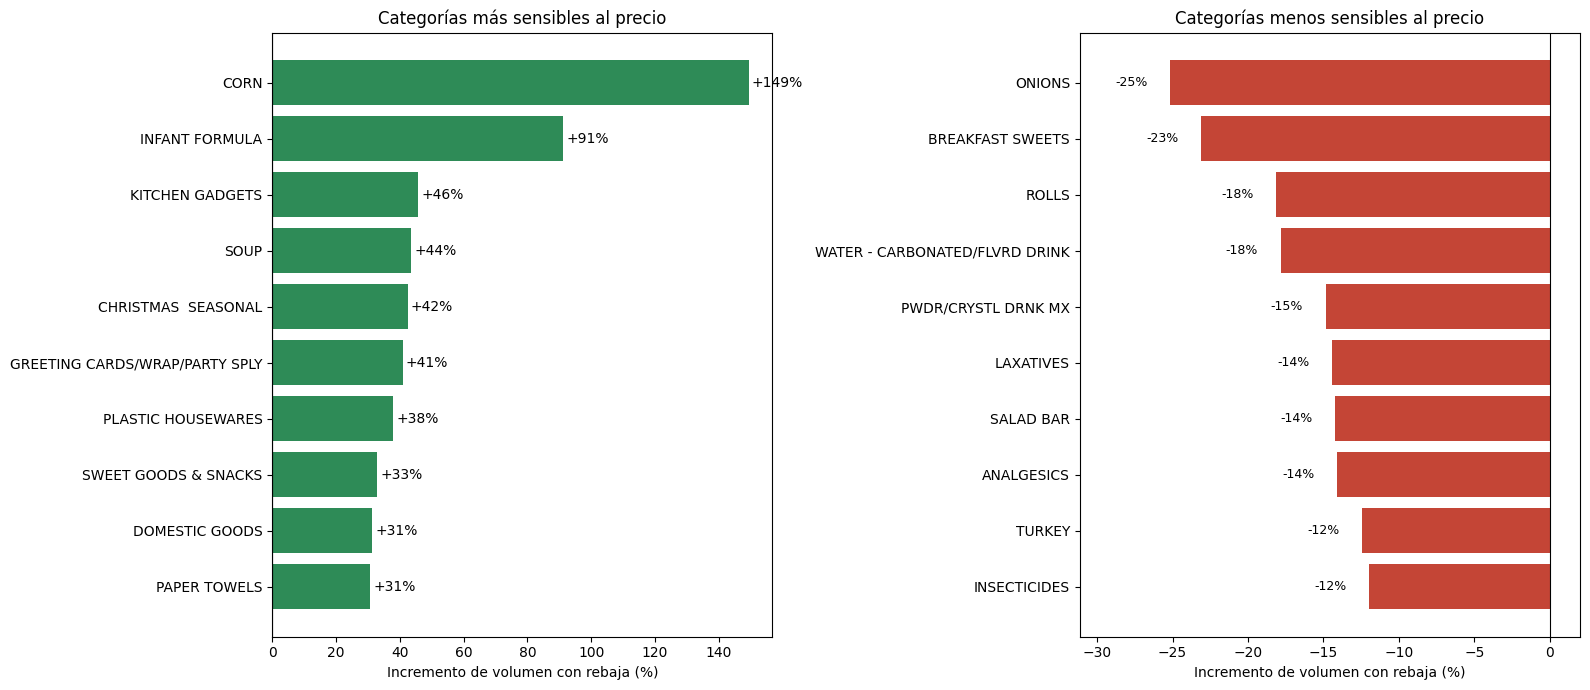

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

top10_ordenado = top10.sort_values('efecto_rebaja_pct')
ax1.barh(top10_ordenado['COMMODITY_DESC'], top10_ordenado['efecto_rebaja_pct'], color='#2E8B57')
ax1.set_xlabel('Incremento de volumen con rebaja (%)')
ax1.set_title('Categorías más sensibles al precio')
ax1.axvline(0, color='black', linewidth=0.8)

for i, (_, fila) in enumerate(top10_ordenado.iterrows()):
    ax1.text(fila['efecto_rebaja_pct'] + 1, i, f"+{fila['efecto_rebaja_pct']:.0f}%", va='center')

bottom10_ordenado = bottom10.sort_values('efecto_rebaja_pct', ascending=False)
ax2.barh(bottom10_ordenado['COMMODITY_DESC'], bottom10_ordenado['efecto_rebaja_pct'], color='#C44536')
ax2.set_xlabel('Incremento de volumen con rebaja (%)')
ax2.set_title('Categorías menos sensibles al precio')
ax2.axvline(0, color='black', linewidth=0.8)

for i, (_, fila) in enumerate(bottom10_ordenado.iterrows()):
    ax2.text(fila['efecto_rebaja_pct'] - 1.5, i, f"{fila['efecto_rebaja_pct']:.0f}%",
             va='center', ha='right', fontsize=9)
ax2.set_xlim(bottom10_ordenado['efecto_rebaja_pct'].min() - 6, 2)

plt.tight_layout()
plt.show()

In [49]:
RUTA_FIGURAS = '/content/drive/MyDrive/UCM -master Data Science/TFM/figuras/'
import os
os.makedirs(RUTA_FIGURAS, exist_ok=True)
fig.savefig(RUTA_FIGURAS + 'elasticidad_top_bottom.png', dpi=150, bbox_inches='tight')


Un resultado que llama la atención: de 211 categorías, 175 salen
"inelásticas" y algunas incluso negativas (ONIONS -25%, BREAKFAST
SWEETS -23%, ROLLS -18%). ¿Significa que rebajar cebollas hace que
la gente compre menos? No, y hay dos razones que lo explican.

Primero, en productos frescos un precio bajo no siempre es una
promoción, sino sobreoferta de temporada: cuando hay mucha cosecha
de cebolla, el precio cae solo, sin cartel ni display. La gente
compra lo que necesita, no más. Así que en esos casos estoy
midiendo estacionalidad de oferta, no respuesta a una promoción.

Segundo, mi métrica es cantidad por transacción, no volumen total.
El efecto de una rebaja puede verse en cuánta gente compra o en
cuánto compra cada uno, y esta métrica solo capta lo segundo. Por
eso destacan productos donde el consumidor puede llevarse más de
uno sin que se estropee: alimentación de despensa como CORN (+149%)
o INFANT FORMULA (+91%), pero también artículos no alimentarios de
compra múltiple como KITCHEN GADGETS (+46%) o CHRISTMAS SEASONAL
(+42%). En productos frescos y perecederos ese mecanismo no puede
operar, porque la compra está limitada por el consumo inmediato.

Las categorías con mayor sensibilidad al precio son aquellas donde
las rebajas generan un incremento superior al 10% en cantidad por
transacción. En esas categorías la promoción de precio es efectiva.
En el resto, la rebaja no mueve volumen de forma apreciable por esta
vía, aunque conviene interpretar con cautela los valores negativos,
que en frescos reflejan más estacionalidad de oferta que respuesta
promocional.




In [50]:
from google.colab import files

In [51]:
!jupyter nbconvert --to html "/content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/02_Price_Elasticity.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/02_Price_Elasticity.ipynb to html
[NbConvertApp] Writing 411724 bytes to /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/02_Price_Elasticity.html
